# Section A. Daten laden & vorbereiten
1. Verkehrsdaten (CSV der Stadt Zürich) laden

2. Als GeoDataFrame casten

3. Reprojizieren nach WGS84

4. OSM-Straßennetz für Zürich holen

5. Graph aus OSM vorbereiten (gerichteter Graph, bearings, maxspeed, etc.)

➡ Output dieser Section:

- joined_points = Messstellen als GeoDataFrame in WGS84 mit Spalten Richtung, AnzFahrzeuge

- G = OSMnx MultiDiGraph (gerichtet), mit Attributen, inkl. bearing, maxspeed, length

In [16]:
# --- Section A: Daten laden & vorbereiten ---
import pandas as pd
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt

# 1️⃣ Verkehrszähldaten laden
path_csv = "/Users/leonarddost/Downloads/sid_dav_verkehrszaehlung_miv_od2031_2025.csv"  # Pfad anpassen
raw = pd.read_csv(path_csv, low_memory=False)

# Relevante Spalten auswählen
cols = [
    "MSID", "ZSName", "Achse", "Richtung",
    "EKoord", "NKoord",
    "MessungDatZeit", "AnzFahrzeuge"
]
raw = raw[cols].dropna(subset=["EKoord", "NKoord", "AnzFahrzeuge"])

# 2️⃣ GeoDataFrame mit LV95-Koordinaten
gdf_lv95 = gpd.GeoDataFrame(
    raw,
    geometry=gpd.points_from_xy(raw["EKoord"], raw["NKoord"]),
    crs="EPSG:2056"
)

# 3️⃣ Nach WGS84 umprojizieren (damit es zu OSM passt)
joined_points = gdf_lv95.to_crs(4326)

# 4️⃣ Mittelwert über Zeit pro Messstelle & Richtung
joined_points_agg = (
    joined_points
    .groupby(["MSID", "Richtung"])
    .agg({
        "AnzFahrzeuge": "mean",
        "geometry": "first",
        "ZSName": "first",
        "Achse": "first"
    })
    .reset_index()
)

print(f"✅ {len(joined_points_agg):,} Messstellen (mit Richtungen) geladen")
display(joined_points_agg.head())


✅ 212 Messstellen (mit Richtungen) geladen


,MSID,Richtung,AnzFahrzeuge,geometry,ZSName,Achse
0,Z001M001,auswärts,279.867230,POINT (8.53707 47.34106),Seestrasse (Strandbad Wollishofen),Seestrasse
1,Z001M002,einwärts,348.793939,POINT (8.53711 47.34107),Seestrasse (Strandbad Wollishofen),Seestrasse
2,Z002M001,auswärts,224.688187,POINT (8.52992 47.33417),Albisstrasse (Widmerstrasse),Albisstrasse
3,Z002M002,einwärts,280.505075,POINT (8.52998 47.33417),Albisstrasse (Widmerstrasse),Albisstrasse
4,Z003M001,auswärts,153.751022,POINT (8.51789 47.33255),Sood-/Leimbachstrasse,Soodstrasse


📡 Lade Straßennetz für Zürich...
✅ 10,566 Straßenabschnitte geladen
✅ edges_gdf IDs gecastet:         u            v  key
0  453768  11767444238    0
1  453805   1990946417    0
2  453805   5132952919    0
Graph CRS: epsg:4326


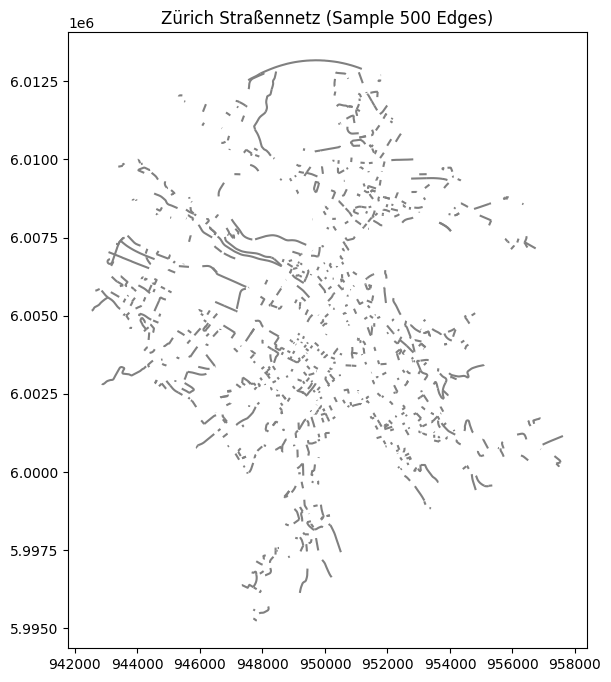

In [17]:
# --- OSM-Netz Zürich laden & vorbereiten ---
import networkx as nx

print("📡 Lade Straßennetz für Zürich...")
G = ox.graph_from_place("Zürich, Switzerland", network_type="drive")

# Bearings & Geschwindigkeiten hinzufügen
G = ox.add_edge_bearings(G)
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

# Als GeoDataFrame exportieren
edges_gdf = ox.graph_to_gdfs(G, nodes=False, edges=True)
print(f"✅ {len(edges_gdf):,} Straßenabschnitte geladen")

# Index (u,v,key) in Spalten umwandeln
edges_gdf = edges_gdf.reset_index()

# --- Knoten-IDs stabilisieren (wichtig für spätere Lookups) ---
edges_gdf["u"] = edges_gdf["u"].astype(int)
edges_gdf["v"] = edges_gdf["v"].astype(int)
edges_gdf["key"] = edges_gdf["key"].astype(int)

print("✅ edges_gdf IDs gecastet:", edges_gdf[["u","v","key"]].head(3))

# CRS check
print("Graph CRS:", edges_gdf.crs)

# Vorschaumap zur Kontrolle
edges_gdf.to_crs(3857).sample(1000).plot(figsize=(8,8), color="grey")
plt.title("Zürich Straßennetz (Sample 500 Edges)")
plt.show()


In [18]:
# --- Sicherstellen, dass es wieder ein GeoDataFrame ist ---
joined_points_agg = gpd.GeoDataFrame(
    joined_points_agg,
    geometry="geometry",
    crs="EPSG:4326"
)

# --- Optional: lokalen Ordner für Daten anlegen ---
import os

os.makedirs("data", exist_ok=True)

# --- Jetzt speichern ---
joined_points_agg.to_file("data/verkehrszaehler_agg.gpkg", layer="points", driver="GPKG")
edges_gdf.to_file("data/zuerich_osm_strassennetz.gpkg", layer="edges", driver="GPKG")

print("💾 Daten gespeichert unter ./data/")

💾 Daten gespeichert unter ./data/


# Section B. Seeds bauen
- Jede Messzeile ⇒ finde nächste Edge im Graph

- Entscheide, ob die Richtung der Zeile einwärts oder auswärts zur Edge-Orientierung passt → wähle passende Kantenrichtung (u→v vs v→u)

- Erzeuge Liste seeds = [{u, v, key, flow, richtung}]

➡ Output dieser Section:

- seeds = Startflüsse mit korrekter Richtung

In [19]:
# --- Section B: Seeds erzeugen (gerichtete Startflüsse) ---
import numpy as np
from shapely.geometry import Point
import osmnx as ox

# 🔹 1. Referenzpunkt: Zürich HB
zurich_hb = Point(8.540192, 47.378177)  # Hauptbahnhof Zürich

# 🔹 2. Richtung relativ zum HB bestimmen
def edge_direction_towards_hb(G, u, v, key):
    u_node = G.nodes[u]
    v_node = G.nodes[v]
    pu = Point(u_node["x"], u_node["y"])
    pv = Point(v_node["x"], v_node["y"])
    return pv.distance(zurich_hb) < pu.distance(zurich_hb)

# 🔹 3. Nächste Straßenkante finden
def snap_point_to_edge_seed(G, point_geom, max_snap_dist=50):
    """
    Findet die nächste Edge (u,v,key) im OSM-Graph.
    Verwirft Punkte, die >max_snap_dist Meter entfernt sind.
    """
    try:
        u, v, key, dist = ox.distance.nearest_edges(G, point_geom.x, point_geom.y, return_dist=True)
        if dist > max_snap_dist:
            return None
        if not G.has_edge(u, v, key):
            if G.has_edge(v, u, key):
                u, v = v, u
            else:
                return None
        return int(u), int(v), int(key), dist
    except Exception:
        return None

# 🔹 4. Seeds erzeugen
seeds = []
invalid_count = 0

for idx, row in joined_points_agg.iterrows():
    geom = row.geometry
    if geom is None or geom.is_empty:
        invalid_count += 1
        continue

    richtung_raw = str(row.get("Richtung", "")).strip().lower()
    flow_val = float(row.get("AnzFahrzeuge", np.nan))
    if not np.isfinite(flow_val) or flow_val <= 0:
        continue

    snapped = snap_point_to_edge_seed(G, geom, max_snap_dist=50)
    if not snapped:
        invalid_count += 1
        continue

    u, v, key, dist = snapped
    towards_hb = edge_direction_towards_hb(G, u, v, key)

    def make_seed(u, v, key, flow, richtung_label):
        return {
            "u": u,
            "v": v,
            "key": key,
            "flow": flow,
            "richtung": richtung_label,
            "x": geom.x,
            "y": geom.y
        }

    if richtung_raw == "einwärts":
        if towards_hb:
            seeds.append(make_seed(u, v, key, flow_val, "einwärts"))
        else:
            seeds.append(make_seed(v, u, key, flow_val, "einwärts"))

    elif richtung_raw == "auswärts":
        if towards_hb:
            seeds.append(make_seed(v, u, key, flow_val, "auswärts"))
        else:
            seeds.append(make_seed(u, v, key, flow_val, "auswärts"))

    else:
        # 50/50-Regel bei unbekannter Richtung
        half = flow_val * 0.5
        if towards_hb:
            seeds.append(make_seed(u, v, key, half, "einwärts"))
            seeds.append(make_seed(v, u, key, half, "auswärts"))
        else:
            seeds.append(make_seed(v, u, key, half, "einwärts"))
            seeds.append(make_seed(u, v, key, half, "auswärts"))

# 🔹 5. Ergebnisbericht
print("====================================")
print(f"✅ Seeds erzeugt: {len(seeds)} total")
print(f"⚠️ Ungültige / nicht gesnapte Messstellen: {invalid_count}")
if seeds:
    print("🔎 Beispiel-Seed:", seeds[0])
else:
    print("❗ Keine Seeds erzeugt – prüfen, ob Messpunkte in Zürich liegen oder max_snap_dist zu klein ist.")
print("====================================")


✅ Seeds erzeugt: 0 total
⚠️ Ungültige / nicht gesnapte Messstellen: 208
❗ Keine Seeds erzeugt – prüfen, ob Messpunkte in Zürich liegen oder max_snap_dist zu klein ist.


In [5]:
test_seed = seeds[0]
print("👁 Seed-Kante:", test_seed)

edge_exists = G.has_edge(test_seed["u"], test_seed["v"], test_seed["key"])
print("Existiert diese Kante im Graph G?:", edge_exists)

if not edge_exists:
    print("❌ Problem: Diese Seed-Kante ist nicht im Graph vorhanden. Dann müssen wir anders snappen.")
else:
    print("✅ Diese Seed-Kante ist im Graph vorhanden. Wir können propagieren.")


👁 Seed-Kante: {'u': 74926632, 'v': 372762234, 'key': 0, 'flow': 279.8672304439746, 'richtung': 'auswärts'}
Existiert diese Kante im Graph G?: True
✅ Diese Seed-Kante ist im Graph vorhanden. Wir können propagieren.


# Section C. Propagation

- Wir laufen den Fluss über das Netz

- An jedem Knoten verteilen wir weiter nach Heuristik (Straßentyp, Winkel, maxspeed)

- Dämpfung mit Distanz und maxspeed

- Stoppen bei max_dist (z. B. 1000 m)

- Stoppen, wenn wir über eine Edge kommen, die schon von einer echten Messstelle versorgt wird

➡ Output dieser Section:

- flow_dict[(u,v,key)] = flow_est Fahrzeuge/h

## 1. Aufsetzten vom Graph

In [6]:
import osmnx as ox

# ⚙️ Straßennetz laden
place_name = "Zürich, Switzerland"
print(f"📡 Lade OSM-Straßennetz für {place_name} ...")

G = ox.graph_from_place(
    place_name,
    network_type="drive",
    simplify=True
)
print("✅ Graph geladen:", len(G.nodes), "Knoten,", len(G.edges), "Kanten")

# 🧭 Bearings und Geschwindigkeiten hinzufügen
G = ox.add_edge_bearings(G)
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

# 🗺️ GeoDataFrames extrahieren (behalten MultiIndex!)
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G, nodes=True, edges=True)
print("✅ edges_gdf & nodes_gdf erzeugt:", len(edges_gdf), "Kanten")


📡 Lade OSM-Straßennetz für Zürich, Switzerland ...
✅ Graph geladen: 4623 Knoten, 10566 Kanten
✅ edges_gdf & nodes_gdf erzeugt: 10566 Kanten


## 2. Seed-Erzeugung

In [13]:
import numpy as np
from shapely.geometry import Point
import osmnx as ox

# =========================================================
# Zentrale Referenz: Zürich HB (für Richtung "einwärts")
# =========================================================
zurich_hb = Point(8.540192, 47.378177)  # ca. HB / Central

# =========================================================
# Hilfsfunktionen
# =========================================================

def edge_direction_towards_hb(G, u, v, key):
    """
    Bestimmt, ob die Kante u->v Richtung Zürich HB führt.
    """
    u_node = G.nodes[u]
    v_node = G.nodes[v]
    pu = Point(u_node["x"], u_node["y"])
    pv = Point(v_node["x"], v_node["y"])
    return pv.distance(zurich_hb) < pu.distance(zurich_hb)


def snap_point_to_edge_seed(G, point_geom, max_snap_dist=50):
    """
    Findet die nächste Edge im Graphen, prüft Distanz und Gültigkeit.
    Gibt (u, v, key, dist) zurück oder None, wenn keine passende Edge.
    """
    try:
        u, v, key, dist = ox.distance.nearest_edges(G, point_geom.x, point_geom.y, return_dist=True)

        # Validierung: maximal erlaubte Distanz
        if dist > max_snap_dist:
            return None

        # Prüfe, ob Edge im Graph existiert, ggf. umkehren
        if not G.has_edge(u, v, key):
            if G.has_edge(v, u, key):
                u, v = v, u
            else:
                return None

        return int(u), int(v), int(key), dist

    except Exception:
        return None


# =========================================================
# Seed-Erzeugung
# =========================================================

seeds = []
invalid_count = 0

for idx, row in joined_points_agg.iterrows():
    geom = row.geometry

    # Sicherheitscheck
    if geom is None or geom.is_empty:
        continue

    x, y = geom.x, geom.y
    richtung_raw = str(row.get("Richtung", "")).strip().lower()
    flow_val = float(row.get("AnzFahrzeuge", np.nan))

    # Überspringe unbrauchbare Werte
    if not np.isfinite(flow_val) or flow_val <= 0:
        continue

    # --- Punkt auf nächste Edge snappen ---
    snap = snap_point_to_edge_seed(G, geom)
    if not snap:
        invalid_count += 1
        print(f"⚠️ Messstelle {idx}: kein valider Straßenanschluss (zu weit oder isoliert)")
        continue

    u, v, key, dist = snap

    # --- Richtung bestimmen ---
    towards_hb = edge_direction_towards_hb(G, u, v, key)

    def make_seed(u, v, key, flow, richtung_label):
        return {
            "u": u,
            "v": v,
            "key": key,
            "flow": flow,
            "richtung": richtung_label,
            "x": x,
            "y": y
        }

    # --- Seeds je nach Richtung ---
    if richtung_raw == "einwärts":
        if towards_hb:
            seeds.append(make_seed(u, v, key, flow_val, "einwärts"))
        else:
            seeds.append(make_seed(v, u, key, flow_val, "einwärts"))

    elif richtung_raw == "auswärts":
        if towards_hb:
            seeds.append(make_seed(v, u, key, flow_val, "auswärts"))
        else:
            seeds.append(make_seed(u, v, key, flow_val, "auswärts"))

    else:
        # Unbekannt -> 50:50 Split
        half = flow_val * 0.5
        if towards_hb:
            seeds.append(make_seed(u, v, key, half, "einwärts"))
            seeds.append(make_seed(v, u, key, half, "auswärts"))
        else:
            seeds.append(make_seed(v, u, key, half, "einwärts"))
            seeds.append(make_seed(u, v, key, half, "auswärts"))

# =========================================================
# Ergebnisbericht
# =========================================================

print(f"✅ Seeds erzeugt: {len(seeds)} total")
print(f"⚠️ Ungültige oder nicht gesnapte Messstellen: {invalid_count}")
if len(seeds) > 0:
    print("Beispiel-Seed:", seeds[0])


⚠️ Messstelle 0: kein valider Straßenanschluss (zu weit oder isoliert)
⚠️ Messstelle 1: kein valider Straßenanschluss (zu weit oder isoliert)
⚠️ Messstelle 2: kein valider Straßenanschluss (zu weit oder isoliert)
⚠️ Messstelle 3: kein valider Straßenanschluss (zu weit oder isoliert)
⚠️ Messstelle 4: kein valider Straßenanschluss (zu weit oder isoliert)
⚠️ Messstelle 5: kein valider Straßenanschluss (zu weit oder isoliert)
⚠️ Messstelle 6: kein valider Straßenanschluss (zu weit oder isoliert)
⚠️ Messstelle 7: kein valider Straßenanschluss (zu weit oder isoliert)
⚠️ Messstelle 8: kein valider Straßenanschluss (zu weit oder isoliert)
⚠️ Messstelle 9: kein valider Straßenanschluss (zu weit oder isoliert)
⚠️ Messstelle 10: kein valider Straßenanschluss (zu weit oder isoliert)
⚠️ Messstelle 11: kein valider Straßenanschluss (zu weit oder isoliert)
⚠️ Messstelle 14: kein valider Straßenanschluss (zu weit oder isoliert)
⚠️ Messstelle 15: kein valider Straßenanschluss (zu weit oder isoliert)
⚠️

## 3.0 Define Propagation

In [8]:
import math
from shapely.geometry import Point

def propagate_flows_v2(G, seeds, max_dist=3000, junction_loss=0.1, stop_radius=100):
    """
    Verbesserte Verkehrsfluss-Propagation:
    - lineare Dämpfung bis max_dist
    - Top-1/2 Routing
    - Stopp bei neuer Messstation
    """

    flow_sum_on_edge = {}
    flow_max_on_edge = {}

    # Hole alle Seed-Koordinaten für spätere Distanzprüfung
    seed_points = [Point(s["x"], s["y"]) for s in seeds]

    for i, seed in enumerate(seeds):
        try:
            u0, v0, k0 = seed["u"], seed["v"], seed["key"]
            F0 = seed["flow"]
            bearing0 = G[u0][v0][k0].get("bearing", None)

            if not G.has_edge(u0, v0, k0):
                continue

            # Initialisieren
            stack = [(u0, v0, k0, 0.0, F0, bearing0)]

            while stack:
                u, v, k, dist, flow_here, bearing_prev = stack.pop()

                edge_data = G[u][v][k]
                length = edge_data.get("length", 0)
                speed = edge_data.get("speed_kph", 30)
                bearing = edge_data.get("bearing", bearing_prev)

                # --- Linearer Decay ---
                new_dist = dist + length
                if new_dist > max_dist:
                    continue
                decay_factor = max(0, 1 - new_dist / max_dist)
                flow_here *= decay_factor * (1 - junction_loss)

                # --- Sammeln ---
                edge_id = (u, v, k)
                flow_sum_on_edge[edge_id] = flow_sum_on_edge.get(edge_id, 0) + flow_here
                flow_max_on_edge[edge_id] = max(flow_max_on_edge.get(edge_id, 0), flow_here)

                # --- Stop bei anderer Messstation ---
                p = Point(edge_data["geometry"].coords[-1])
                if any(p.distance(pt) < stop_radius for pt in seed_points if pt != Point(seed["x"], seed["y"])):
                    continue

                # --- Weiterleiten an Nachbarn ---
                if G.out_degree(v) == 0:
                    continue

                candidates = []
                for vv, kk, data2 in G.out_edges(v, keys=True, data=True):
                    if data2 is None or not data2.get("geometry"):
                        continue
                    bearing2 = data2.get("bearing", bearing)
                    delta_bearing = abs(bearing - bearing2)
                    delta_bearing = min(delta_bearing, 360 - delta_bearing)
                    cos_score = math.cos(math.radians(delta_bearing))
                    speed2 = data2.get("speed_kph", 30)
                    score = cos_score * (speed2 / 100)
                    candidates.append((vv, kk, data2, score))

                if not candidates:
                    continue

                # nur Top 2 Kandidaten
                candidates.sort(key=lambda x: x[3], reverse=True)
                top = candidates[:2]

                total_score = sum(c[3] for c in top)
                if total_score == 0:
                    continue

                for vv, kk, data2, score in top:
                    share = score / total_score
                    flow_next = flow_here * share
                    if flow_next < 1:  # cutoff für sehr kleinen Restfluss
                        continue
                    stack.append((v, vv, kk, new_dist, flow_next, bearing))
        except Exception as e:
            print(f"⚠️ Fehler bei Seed {i}: {e}")

    print(f"✅ Propagation abgeschlossen – {len(flow_sum_on_edge):,} Kanten mit Flusswerten.")
    return flow_sum_on_edge, flow_max_on_edge


## 3.1 Propagation durchführen

In [9]:
# Füge fehlende Geometrien hinzu
import shapely.geometry as geom

missing_geom = 0
for u, v, k, data in G.edges(keys=True, data=True):
    if "geometry" not in data or data["geometry"] is None:
        try:
            u_node = G.nodes[u]
            v_node = G.nodes[v]
            line = geom.LineString([(u_node["x"], u_node["y"]), (v_node["x"], v_node["y"])])
            data["geometry"] = line
            missing_geom += 1
        except Exception:
            pass

print(f"✅ Fehlende Geometrien ergänzt: {missing_geom}")


✅ Fehlende Geometrien ergänzt: 922


In [10]:
flow_sum_on_edge, flow_max_on_edge = propagate_flows_v2(
    G,
    seeds,
    max_dist=3000,        # Reichweite 3 km
    junction_loss=0.1,    # 10 % Verlust je Kreuzung
    stop_radius=100       # bei 100 m anderer Messstelle stoppen
)

edges_gdf["edge_id"] = list(zip(edges_gdf.index.get_level_values(0),
                                edges_gdf.index.get_level_values(1),
                                edges_gdf.index.get_level_values(2)))
edges_gdf["flow_sum"] = edges_gdf["edge_id"].map(flow_sum_on_edge).fillna(0)
edges_gdf["flow_max"] = edges_gdf["edge_id"].map(flow_max_on_edge).fillna(0)


⚠️ Fehler bei Seed 22: 524847719
⚠️ Fehler bei Seed 26: 3549824262
⚠️ Fehler bei Seed 44: 1470881025
⚠️ Fehler bei Seed 47: 2894177687
⚠️ Fehler bei Seed 49: 29382395
⚠️ Fehler bei Seed 50: 149464082
⚠️ Fehler bei Seed 52: 149464082
⚠️ Fehler bei Seed 55: 29382395
⚠️ Fehler bei Seed 60: 26114488
⚠️ Fehler bei Seed 63: 1853111099
⚠️ Fehler bei Seed 69: 445397477
⚠️ Fehler bei Seed 70: 154607529
⚠️ Fehler bei Seed 79: 29353723
⚠️ Fehler bei Seed 80: 29353694
⚠️ Fehler bei Seed 94: 252458199
⚠️ Fehler bei Seed 97: 84491994
⚠️ Fehler bei Seed 98: 3808303323
⚠️ Fehler bei Seed 104: 4392778978
⚠️ Fehler bei Seed 107: 4392778978
⚠️ Fehler bei Seed 114: 140402611
⚠️ Fehler bei Seed 117: 140403043
⚠️ Fehler bei Seed 122: 1422693067
⚠️ Fehler bei Seed 126: 5295634075
⚠️ Fehler bei Seed 129: 34945961
⚠️ Fehler bei Seed 130: 6291981224
⚠️ Fehler bei Seed 133: 1396809788
⚠️ Fehler bei Seed 134: 26114485
⚠️ Fehler bei Seed 137: 3813718387
⚠️ Fehler bei Seed 139: 173494048
⚠️ Fehler bei Seed 140: 436

# Section D. Karte

- flow_dict zurück in edges_gdf

- Plotten auf Basemap

/var/folders/5h/7hhdw_3j1bz_15_wtp0jmb_80000gn/T/ipykernel_57109/222552071.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma")
/var/folders/5h/7hhdw_3j1bz_15_wtp0jmb_80000gn/T/ipykernel_57109/222552071.py:93: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/leonarddost/localPythonProjects/CIP/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


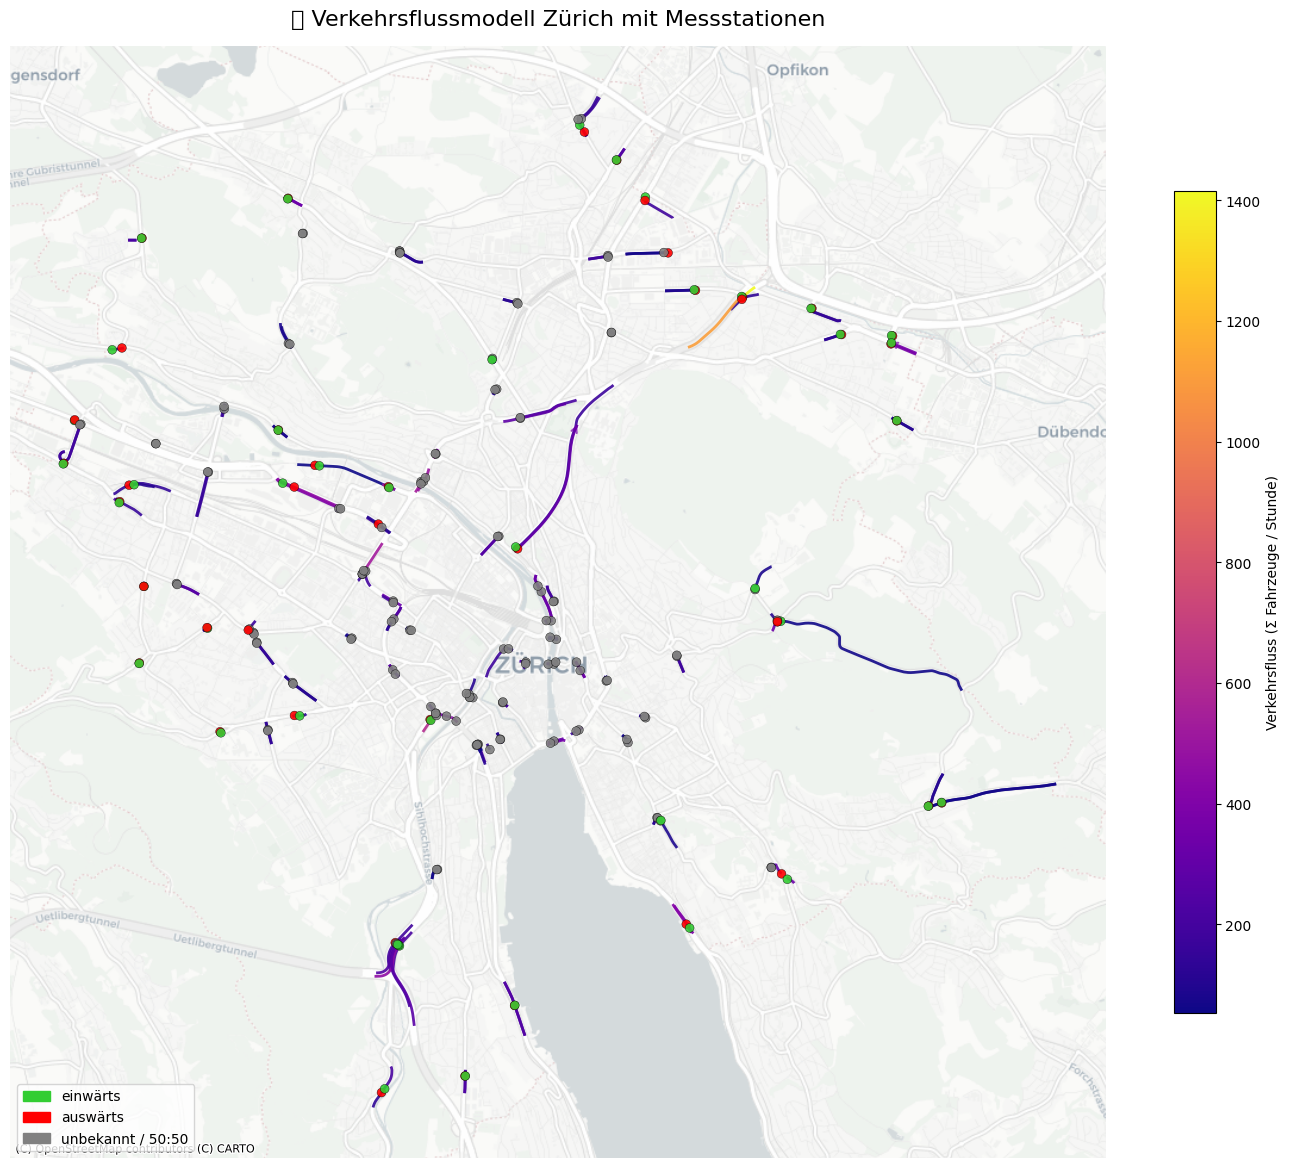

In [11]:
import matplotlib.pyplot as plt
import contextily as ctx
import matplotlib.patches as mpatches
from shapely.geometry import LineString
import numpy as np
import matplotlib.cm as cm

# --- Vorbereitung ---
edges_flow = edges_gdf[edges_gdf["flow_sum"] > 50].copy()
edges_web = edges_flow.to_crs(3857)
points_web = joined_points_agg.to_crs(3857)

# --- Plot-Basis ---
fig, ax = plt.subplots(figsize=(14, 14))

# 1️⃣ Linien nach Verkehrsfluss färben
lineplot = edges_web.plot(
    ax=ax,
    column="flow_sum",
    cmap="plasma",
    linewidth=2.0,
    legend=True,
    legend_kwds={
        "label": "Verkehrsfluss (Σ Fahrzeuge / Stunde)",
        "shrink": 0.6
    },
    alpha=0.9,
    zorder=2
)

# 2️⃣ Dezente farbige Richtungspfeile (Variante B)
cmap = cm.get_cmap("plasma")
np.random.seed(42)  # für Reproduzierbarkeit

for i, row in edges_web.iterrows():
    if row["flow_sum"] <= 200:        # Schwellenwert – nur bei signifikantem Fluss
        continue
    if np.random.rand() > 0.05:       # nur ~5 % der Kanten kriegen Pfeile
        continue

    geom = row.geometry
    if not isinstance(geom, LineString):
        continue
    coords = list(geom.coords)
    if len(coords) < 2:
        continue

    # Endsegmente der Linie für Richtungspfeil
    x0, y0 = coords[-2]
    x1, y1 = coords[-1]

    # Farbe = gleiche Colormap wie Linien
    col = cmap(min(row["flow_sum"] / edges_web["flow_sum"].max(), 1.0))

    ax.annotate(
        "",
        xy=(x1, y1), xytext=(x0, y0),
        arrowprops=dict(
            arrowstyle="->",
            color=col,
            linewidth=1.5,
            alpha=0.7
        ),
        zorder=4
    )

# 3️⃣ Messstationen (Richtung einfärben)
colors = {"einwärts": "limegreen", "auswärts": "red", "unbekannt": "gray"}
points_web.plot(
    ax=ax,
    color=points_web["Richtung"].str.lower().map(colors).fillna("gray"),
    markersize=40,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.3,
    zorder=5
)

# 4️⃣ Basemap hinzufügen
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=edges_web.crs)

# 5️⃣ Layout und Legende
ax.set_title("🚗 Verkehrsflussmodell Zürich mit Messstationen", fontsize=16, pad=15)
ax.set_axis_off()

patches = [
    mpatches.Patch(color="limegreen", label="einwärts"),
    mpatches.Patch(color="red", label="auswärts"),
    mpatches.Patch(color="gray", label="unbekannt / 50:50"),
]
ax.legend(handles=patches, loc="lower left")

plt.tight_layout()
plt.show()


In [12]:
# PNG (Standard, hohe Auflösung)
fig.savefig("/Users/leonarddost/Downloads/plot3", dpi=300, bbox_inches="tight")

/var/folders/5h/7hhdw_3j1bz_15_wtp0jmb_80000gn/T/ipykernel_57109/1159964421.py:2: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.savefig("/Users/leonarddost/Downloads/plot3", dpi=300, bbox_inches="tight")
